In [2]:
import numpy as nb 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


sns.set_style('whitegrid')

pd.set_option('display.max_columns',None)

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../data/raw/data.csv")

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [7]:
df = df.drop(columns=["EmployeeNumber"])

In [8]:
df.info(verbose=True)


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  Gender                    1470 non-null   str  
 11  HourlyRate                1470 non-null   int64
 12  JobInvolvement            1470 non-null   int64
 13  JobLevel                  1470 non-null   int64
 14  JobRole                   1470 non-null   str  
 15

In [9]:
df.select_dtypes(include='object').columns.tolist()

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [10]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithC

In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
WorkLifeBalance                4
RelationshipSatisfaction       4
StockOptionLevel               4
EnvironmentSatisfaction        4
JobInvolvement                 4
JobSatisfaction                4
JobLevel                       5
Education                      5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [15]:
constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]
constant_columns

['EmployeeCount', 'Over18', 'StandardHours']

In [16]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [17]:
(df["Attrition"].value_counts(normalize=True) * 100).round(2)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

In [18]:
# sns.countplot(data=df,x=df.Attrition)

In [19]:
continuous_columns = df.select_dtypes(include=['int64','float64']).columns.to_list()
categorical_columns = df.select_dtypes(include=['object','str']).columns.to_list()

print("Numerical Columns:")
print(continuous_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [20]:
df[continuous_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.0,1.0,1.00,1.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0


In [21]:
# df[continuous_columns].hist(
#     figsize=(18,15),
#     bins=20
# )
# plt.tight_layout()
# plt.show()

In [22]:
# plt.figure(figsize=(18,15))

# for i, col in enumerate(continuous_columns, 1):
#     plt.subplot(5, 6, i)
#     sns.boxplot(y=df[col])
#     plt.title(col)

# plt.tight_layout()
# plt.show()

In [23]:
# plt.figure(figsize=(18,20))

# for i, col in enumerate(categorical_columns, 1):
#     plt.subplot(3, 3, i)
#     sns.countplot(data=df, x=col)
#     plt.xticks(rotation=45)
#     plt.title(col)

# plt.tight_layout()
# plt.show()

In [24]:
# plt.figure(figsize=(6,4))

# sns.countplot(
#     data=df,
#     x="OverTime",
#     hue="Attrition",
#     palette="Set2"
# )

# plt.title("Attrition by Overtime")
# plt.xlabel("OverTime")
# plt.ylabel("Number of Employees")

# plt.show()

In [25]:
pd.crosstab(df["OverTime"], df["Attrition"])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [26]:
pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [27]:
categorical_columns

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [28]:
# plt.figure(figsize=(6,4))

# sns.countplot(
#     data=df,
#     x="JobSatisfaction",
#     hue="Attrition",
#     palette="Set2"
# )

# plt.title("Attrition by Overtime")
# plt.xlabel("JobSatisfaction")
# plt.ylabel("Number of Employees")

# plt.show()

In [29]:
# plt.figure(figsize=(8,5))

# sns.boxplot(
#     data=df,
#     x="Attrition",
#     y="MonthlyIncome",
#     palette="Set2"
# )

# plt.title("Monthly Income vs Attrition")
# plt.xlabel("Attrition")
# plt.ylabel("Monthly Income")

# plt.show()

In [30]:
df_corr = df.drop(columns=["EmployeeCount", "Over18", "StandardHours"])

In [31]:
df_corr.Attrition = df.Attrition.map({
    "Yes" : 0,
    "No" : 1,

})

In [32]:
# plt.figure(figsize=(16,24))

# sns.heatmap(
#     df_corr.corr(numeric_only=True),
#     cmap="coolwarm",
#     annot=False
# )

# plt.title("Correlation Heatmap")
# plt.show()

## Bivariate Analysis

In [33]:
# # 1. Department vs Attrition
# plt.figure(figsize=(8,5))

# sns.countplot(
#     data=df,
#     x="Department",
#     hue="Attrition",
#     palette="Set2"
# )

# plt.title("Department vs Attrition")
# plt.xticks(rotation=15)
# plt.show()

In [34]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [35]:
# 2. Job Role vs Attrition
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

jobrole_attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


In [36]:
# # 3. Business Travel vs Attrition
# plt.figure(figsize=(7,5))

# sns.countplot(
#     data=df,
#     x="BusinessTravel",
#     hue="Attrition",
#     palette="Set2"
# )

# plt.title("Business Travel vs Attrition")

# plt.show()

In [37]:
travel_attrition = pd.crosstab(
    df["BusinessTravel"],
    df["Attrition"],
    normalize="index"
) * 100

travel_attrition

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


In [38]:
# # 4. Marital Status vs Attrition
# plt.figure(figsize=(7,5))

# sns.countplot(
#     data=df,
#     x="MaritalStatus",
#     hue="Attrition",
#     palette="Set2"
# )

# plt.title("Marital Status vs Attrition")

# plt.show()

In [39]:
marital_attrition = pd.crosstab(
    df["MaritalStatus"],
    df["Attrition"],
    normalize="index"
) * 100

marital_attrition

Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


In [40]:
# department_attrition.plot(
#     kind="bar",
#     stacked=True,
#     figsize=(8,5)
# )

# plt.ylabel("Percentage")
# plt.title("Department-wise Attrition Percentage")

# plt.show()

In [41]:
def analyze_numerical_feature(feature):
    print(f"\n{feature}")
    print("-" * 40)

    print(df.groupby("Attrition")[feature].describe())

    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="Attrition", y=feature ,palette="Set2")
    plt.show()

In [42]:
# analyze_numerical_feature("Age")
# analyze_numerical_feature("MonthlyIncome")
# analyze_numerical_feature("DistanceFromHome")
# analyze_numerical_feature("YearsSinceLastPromotion")

## Data Preprocessing

In [43]:
df = df.drop(columns=constant_columns)


In [44]:
X = df.drop("Attrition" , axis=1)
y = df.Attrition

In [45]:
print(X.shape)
print(y.shape)

(1470, 30)
(1470,)


In [46]:
X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=42 , test_size=0.2,stratify=y)

In [47]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(1176, 30)
(294, 30)
Attrition
No     0.838435
Yes    0.161565
Name: proportion, dtype: float64
Attrition
No     0.840136
Yes    0.159864
Name: proportion, dtype: float64


### Feature Encoding

In [48]:
categorical_columns,continuous_columns

(['Attrition',
  'BusinessTravel',
  'Department',
  'EducationField',
  'Gender',
  'JobRole',
  'MaritalStatus',
  'Over18',
  'OverTime'],
 ['Age',
  'DailyRate',
  'DistanceFromHome',
  'Education',
  'EmployeeCount',
  'EnvironmentSatisfaction',
  'HourlyRate',
  'JobInvolvement',
  'JobLevel',
  'JobSatisfaction',
  'MonthlyIncome',
  'MonthlyRate',
  'NumCompaniesWorked',
  'PercentSalaryHike',
  'PerformanceRating',
  'RelationshipSatisfaction',
  'StandardHours',
  'StockOptionLevel',
  'TotalWorkingYears',
  'TrainingTimesLastYear',
  'WorkLifeBalance',
  'YearsAtCompany',
  'YearsInCurrentRole',
  'YearsSinceLastPromotion',
  'YearsWithCurrManager'])

In [49]:
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

numerical_features = X_train.select_dtypes(exclude="object").columns.tolist()

In [50]:
y_train = y_train.map({
    "No":0,
    "Yes":1
})
y_test = y_test.map({
    "No":0,
    "Yes":1
})

In [51]:
from sklearn.compose import ColumnTransformer

In [52]:
preprocessor = ColumnTransformer(
    transformers = [
        ("number", StandardScaler() , numerical_features ),
        ("category", OneHotEncoder(handle_unknown="ignore") , categorical_features )
    ]
)

In [53]:
X_train.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [54]:
X_train_preprocessor = preprocessor.fit_transform(X_train)
X_test_preprocessor = preprocessor.transform(X_test)

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [56]:
pipeline = Pipeline(
    steps=[
        ("preprocessor" , preprocessor),
        ("classifier" , LogisticRegression(random_state=42))
    ]
)

In [57]:
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('number', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dro

In [58]:
y_pred = pipeline.predict(X_test)

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [60]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8605442176870748
Precision: 0.6153846153846154
Recall   : 0.3404255319148936
F1 Score : 0.4383561643835616


In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



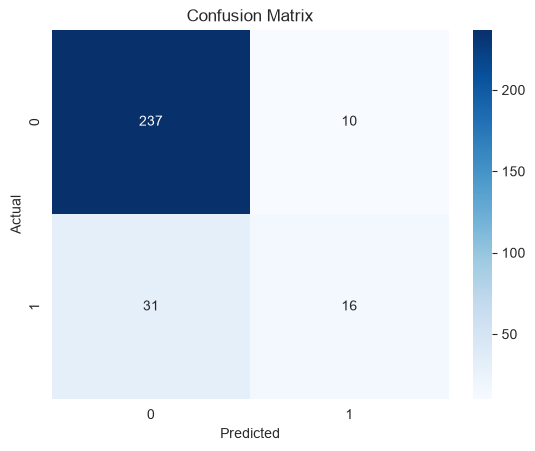

In [62]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Handling Imbalanced Data (SMOTE)

In [63]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

smote_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

In [64]:
smote_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('number', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [65]:
y_pred_smote = smote_pipeline.predict(X_test)

In [66]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.91      0.80      0.85       247
           1       0.36      0.57      0.44        47

    accuracy                           0.77       294
   macro avg       0.63      0.69      0.65       294
weighted avg       0.82      0.77      0.79       294



## Random Forest

In [67]:
from sklearn.ensemble import RandomForestClassifier

In [68]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            n_estimators=100,
            class_weight="balanced"
        ))
    ]
)

In [69]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('number', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [70]:
y_pred_rf = rf_pipeline.predict(X_test)

In [71]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       247
           1       0.49      0.36      0.41        47

    accuracy                           0.84       294
   macro avg       0.68      0.64      0.66       294
weighted avg       0.82      0.84      0.83       294



In [72]:
rf_model = rf_pipeline.named_steps["classifier"]

In [73]:
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

In [74]:

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
9,number__MonthlyIncome,0.074588
16,number__TotalWorkingYears,0.058100
0,number__Age,0.055989
1,number__DailyRate,0.051154
19,number__YearsAtCompany,0.045799
2,number__DistanceFromHome,0.043844
5,number__HourlyRate,0.040900
10,number__MonthlyRate,0.039198
11,number__NumCompaniesWorked,0.037727
22,number__YearsWithCurrManager,0.035233


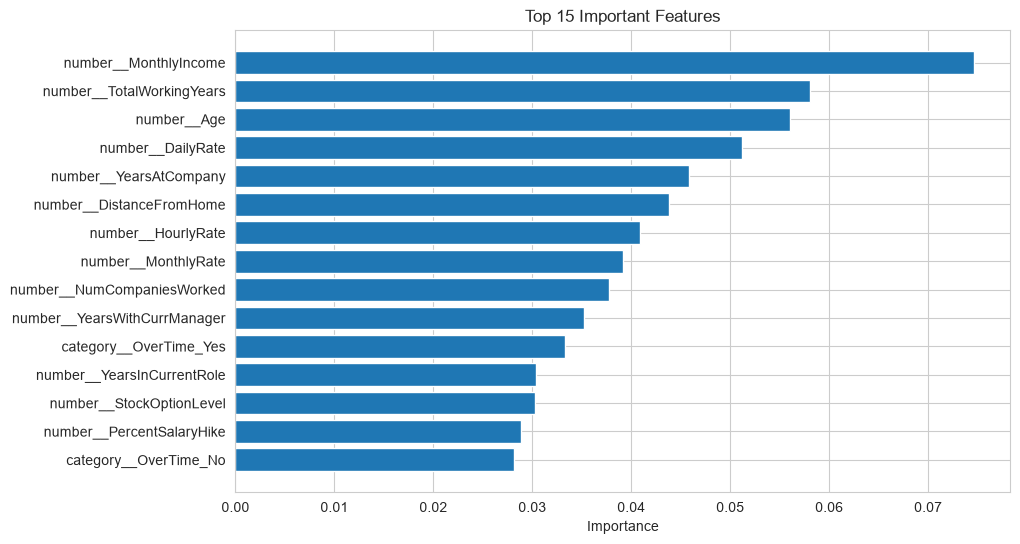

In [75]:

top15 = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(top15["Feature"], top15["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## Explainable AI (SHAP)

In [76]:
import shap

In [77]:
X_train_processed = rf_pipeline.named_steps[
    "preprocessor"
].transform(X_train)

In [78]:
explainer = shap.TreeExplainer(rf_model)

In [79]:
shap_values = explainer.shap_values(X_train_processed)

In [95]:
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

shap.summary_plot(
    shap_values[:, :, 1],
    X_train_processed,
    feature_names=feature_names,
    show=False
)
plt.savefig(
    "../images/shap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close() 

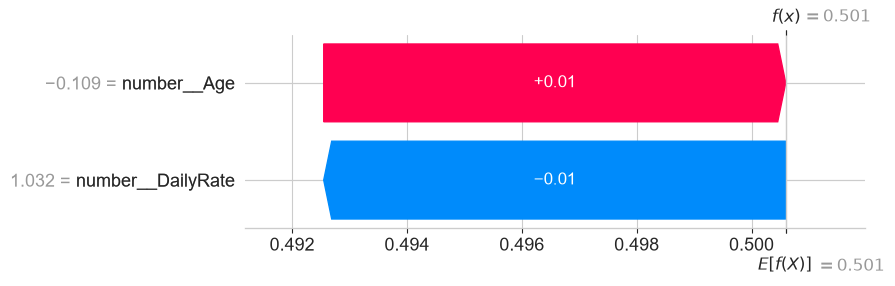

In [83]:
employee_index = 10
shap_values = explainer.shap_values(X_train_processed)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[1][employee_index],
        base_values=explainer.expected_value[1],
        data=X_train_processed[employee_index],
        feature_names=feature_names,
        
    )
    
)

## Hyperparameter tunning

In [84]:
from sklearn.model_selection import RandomizedSearchCV

In [85]:
param_dist = {
    "classifier__n_estimators": [100, 200, 300, 500],

    "classifier__max_depth": [None, 5, 10, 20, 30],

    "classifier__min_samples_split": [2, 5, 10],

    "classifier__min_samples_leaf": [1, 2, 4],

    "classifier__max_features": ["sqrt", "log2"],

    "classifier__class_weight": [None, "balanced"]
}

In [86]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,

    n_iter=20,

    scoring="recall",

    cv=5,

    random_state=42,

    n_jobs=-1 #uses all CPU core 
)

In [87]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` di

In [88]:
print(random_search.best_params_)

{'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 5, 'classifier__class_weight': 'balanced'}


In [89]:
print(random_search.best_score_)

0.5684210526315789


In [90]:
best_model = random_search.best_estimator_

In [91]:
y_pred_best = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           0       0.92      0.84      0.88       247
           1       0.43      0.62      0.50        47

    accuracy                           0.81       294
   macro avg       0.67      0.73      0.69       294
weighted avg       0.84      0.81      0.82       294



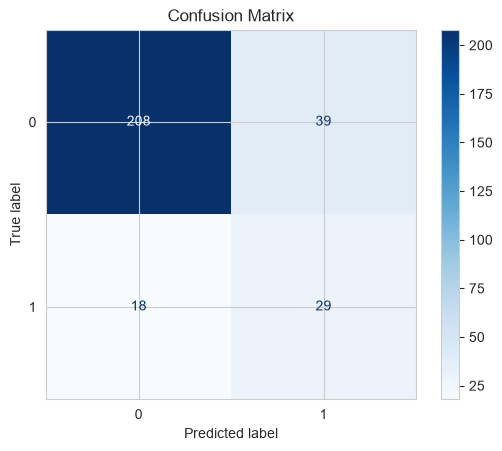

In [92]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [93]:
import joblib

joblib.dump(best_model, "../models/employee_attrition_model.pkl")

['../models/employee_attrition_model.pkl']

In [94]:
print(X.columns.tolist())

['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
